# E-Commerce Sales Analysis using Python

### Tools Used:
- Python
- Pandas
- Matplotlib

### Objective:
Analyze sales data to identify trends, top-performing regions, and profit insights.

## Import libraries

In [3]:
# Import required Libraries

import pandas as pd
import matplotlib.pyplot as plt


## Load Dataset

In [5]:
# Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Understanding

In [6]:
# Check data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:
# Check missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Data Cleaning

In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

In [11]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

## Feature Engineering

In [12]:
# Extract year and month from Order Date
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

In [13]:
# Create Profit Margin column
df['Profit Margin'] = df['Profit'] / df['Sales']

## Key Performance Indicators (KPIs)

In [28]:
# Total Sales
total_sales = df['Sales'].sum()

# Total Profit
total_profit = df['Profit'].sum()

# Total Orders
total_orders = df.shape[0]

# Average Profit Margin
avg_profit_margin = df['Profit Margin'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Avg Profit Margin:", avg_profit_margin)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 9994
Avg Profit Margin: 0.12031392972104459


## Data Analysis

In [24]:
# Total Sales
df['Sales'].sum()

np.float64(2297200.8603000003)

In [15]:
# Total Profit
df['Profit'].sum()

np.float64(286397.0217)

In [16]:
df.shape[0]

9994

In [17]:
# Sales by Region
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


In [18]:
df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [19]:
df.groupby('Month')['Sales'].sum()

,Sales
Month,
1,94924.8356
2,59751.2514
3,205005.4888
4,137762.1286
5,155028.8117
6,152718.6793
7,147238.0970
8,159044.0630
9,307649.9457


In [20]:
df[df['Profit'] < 0].sort_values(by='Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Profit Margin
7772,7773,CA-2016-108196,2016-11-25,12/2/2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,2016,11,November,-1.466667
683,684,US-2017-168116,2017-11-04,11/4/2017,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,2017,11,November,-0.480000
9774,9775,CA-2014-169019,2014-07-26,7/30/2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,2014,7,July,-1.700000
3011,3012,CA-2017-134845,2017-04-17,4/23/2017,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,2017,4,April,-1.333333
4991,4992,US-2017-122714,2017-12-07,12/13/2017,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,2017,12,December,-1.550000
3151,3152,CA-2015-147830,2015-12-15,12/18/2015,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912,2015,12,December,-1.466667
5310,5311,CA-2017-131254,2017-11-19,11/21/2017,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820,2017,11,November,-1.500000
9639,9640,CA-2015-116638,2015-01-28,1/31/2015,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,2015,1,January,-0.433333
1199,1200,CA-2016-130946,2016-04-08,4/12/2016,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464,2016,4,April,-1.700000
2697,2698,CA-2014-145317,2014-03-18,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,2014,3,March,-0.080000


## Correlation Analysis

In [29]:
# Correlation between Sales and Profit
df[['Sales', 'Profit']].corr()

,Sales,Profit
Sales,1.000000,0.479064
Profit,0.479064,1.000000


## Loss-Making Products Analysis

In [30]:
# Products with highest losses
df[df['Profit'] < 0].sort_values(by='Profit').head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,Profit Margin
7772,7773,CA-2016-108196,2016-11-25,12/2/2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,2016,11,November,-1.466667
683,684,US-2017-168116,2017-11-04,11/4/2017,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,2017,11,November,-0.480000
9774,9775,CA-2014-169019,2014-07-26,7/30/2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,2014,7,July,-1.700000
3011,3012,CA-2017-134845,2017-04-17,4/23/2017,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800,2017,4,April,-1.333333
4991,4992,US-2017-122714,2017-12-07,12/13/2017,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845,2017,12,December,-1.550000
3151,3152,CA-2015-147830,2015-12-15,12/18/2015,First Class,NF-18385,Natalie Fritzler,Consumer,United States,Newark,...,Machines,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912,2015,12,December,-1.466667
5310,5311,CA-2017-131254,2017-11-19,11/21/2017,First Class,NC-18415,Nathan Cano,Consumer,United States,Houston,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820,2017,11,November,-1.500000
9639,9640,CA-2015-116638,2015-01-28,1/31/2015,Second Class,JH-15985,Joseph Holt,Consumer,United States,Concord,...,Tables,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124,2015,1,January,-0.433333
1199,1200,CA-2016-130946,2016-04-08,4/12/2016,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Houston,...,Binders,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464,2016,4,April,-1.700000
2697,2698,CA-2014-145317,2014-03-18,3/23/2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,2014,3,March,-0.080000


## Category Performance

In [31]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


## Data Visualization

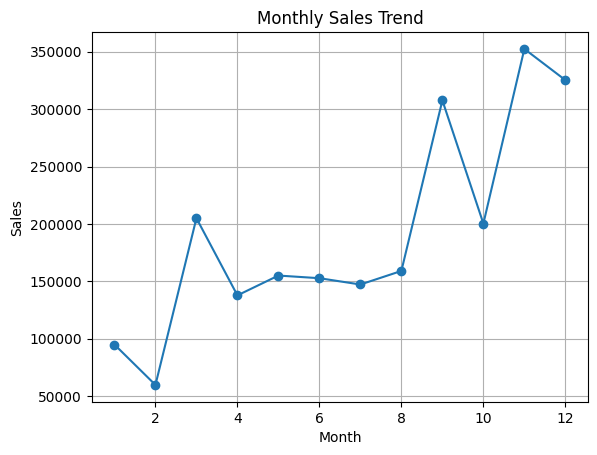

In [25]:
# Monthly sales trend
df.groupby('Month')['Sales'].sum().plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()

plt.show()

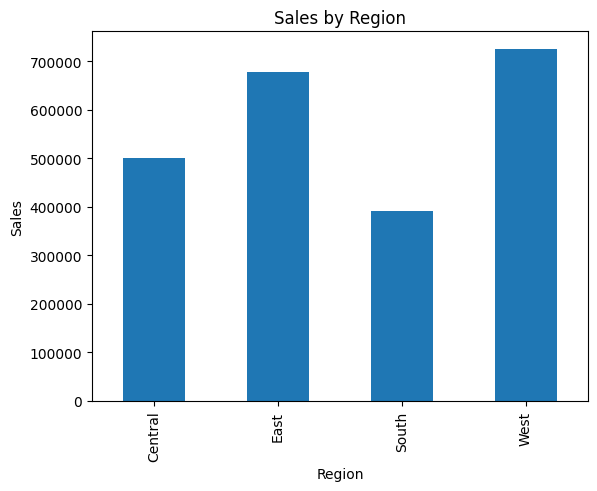

In [26]:
df.groupby('Region')['Sales'].sum().plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

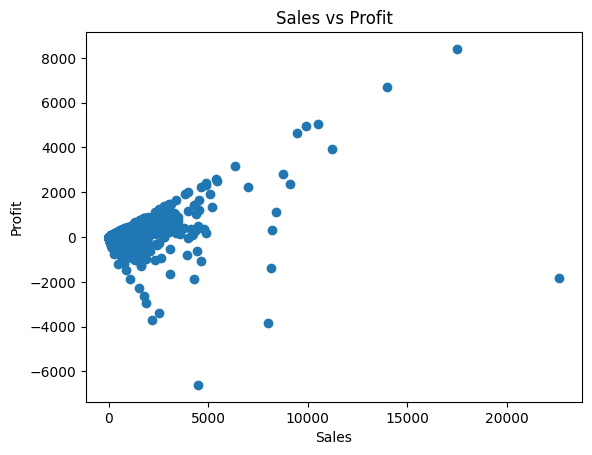

In [23]:
plt.scatter(df['Sales'], df['Profit'])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Final Business Insights

• West region contributes the highest sales, indicating strong market presence  
• Some products generate consistent losses, highlighting need for pricing review  
• Sales trend shows seasonal variation across months  
• Profit is not always proportional to sales, indicating margin issues  
• Certain categories dominate revenue contribution  


## Conclusion

This analysis highlights key sales trends, regional performance, and profitability issues. The insights can help businesses improve pricing strategies, focus on high-performing regions, and optimize product offerings.